In [ ]:
import distutils.spawn
from functools import partial

import jax
from jax import numpy as jnp
from jax import random
from jax.scipy import special as scs
from matplotlib import pyplot as plt
from matplotlib import rc
import pandas as pd
import seaborn as sns

In [2]:
sns.set(font_scale=2.0)
if distutils.spawn.find_executable("latex"):
    rc("font", **{"family": "serif", "serif": ["Computer Modern"]})
    rc("text", usetex=True)

/var/folders/5t/1858x_sn3kz5tw252hv5nw3w0000gn/T/ipykernel_53431/3010401971.py:2: DeprecationWarning: Use shutil.which instead of find_executable
  if distutils.spawn.find_executable("latex"):


In [3]:
# X is a Lxd matrix
@jax.jit
def T(X, params, lambd):
    """Our simplified attention-based predictor."""
    k1, v1, k2, v2 = params
    return scs.erf(lambd * X @ k1).T @ (X @ v1) + scs.erf(lambd * X @ k2).T @ (X @ v2)


batched_T = jax.vmap(T, in_axes=[0, None, None], out_axes=0)

In [4]:
def risk_fn(X, y, params, lambd):
    """Loss with mean-squared error for our problem."""
    return jnp.mean((batched_T(X, params, lambd) - y) ** 2)

grad_fn = jax.value_and_grad(risk_fn, argnums=2)

def init_star(d, key):
    """Initialization of k* and v* on the sphere."""
    subkeys = random.split(key, 2)
    k_star = random.normal(subkeys[0], shape=(d,))
    k_star = k_star / jnp.linalg.norm(k_star)
    v_star = random.normal(subkeys[1], shape=(d,))
    v_star = v_star - k_star @ v_star * k_star
    v_star = v_star / jnp.linalg.norm(v_star)
    return k_star, v_star

def generate_params(d, key):
    # Xavier initialization N(0, 2/(d_in + d_out))
    subkeys = random.split(key, 4)
    k1 = random.normal(subkeys[0], shape=(d,))
    k1 = k1 / jnp.linalg.norm(k1)
    v1 = random.normal(subkeys[1], shape=(d,))
    v1 = v1 / jnp.linalg.norm(v1)
    k2 = random.normal(subkeys[2], shape=(d,))
    k2 = k2 / jnp.linalg.norm(k2)
    v2 = random.normal(subkeys[3], shape=(d,))
    v2 = v2 / jnp.linalg.norm(v2)
    return k1, v1, k2, v2

@partial(jax.jit, static_argnames=["batch_size", "d", "L"])
def generate_batch(list_k_star, list_v_star, batch_size, d, L, eps, gamma, key):
    """Generates one batch of data of the single-location regression distribution."""
    subkeys = random.split(key, 3)
    X_directions = []
    nb_directions = len(list_k_star)
    for k_star in list_k_star:
        X_directions.append(jax.random.multivariate_normal(
            subkeys[0],
            jnp.sqrt(d / 2) * k_star,
            gamma**2 * jnp.eye(d),
            shape=(batch_size, 1),
        ))
    X_directions = jnp.concatenate(X_directions, axis=1)
    other_X_i = jax.random.normal(subkeys[1], shape=(batch_size, L - nb_directions, d))
    xi = eps * jax.random.normal(subkeys[2], shape=(batch_size,))
    all_v_stars = jnp.vstack(list_v_star)
    y = jnp.einsum('ijk,jk->i', X_directions, all_v_stars) + xi
    return jnp.concatenate([X_directions, other_X_i], axis=1), y

@partial(jax.jit, static_argnames=["batch_size", "d", "L"])
def sgd_step(params, list_k_star, list_v_star, d, L, gamma, lambd, alpha, batch_size, eps, key):
    """One step of SGD."""
    X, y = generate_batch(list_k_star, list_v_star, batch_size, d, L, eps, gamma, key)
    risk, grad = grad_fn(X, y, params, lambd)
    k1, v1, k2, v2 = params
    grad_k1_value, grad_v1_value, grad_k2_value, grad_v2_value = grad
    new_k1 = k1 - alpha * (grad_k1_value - k1 @ grad_k1_value * k1)
    new_v1 = v1 - alpha * (grad_v1_value - v1 @ grad_v1_value * v1)
    k1, v1 = new_k1 / jnp.linalg.norm(new_k1), new_v1 / jnp.linalg.norm(new_v1)
    new_k2 = k2 - alpha * (grad_k2_value - k2 @ grad_k2_value * k2)
    new_v2 = v2 - alpha * (grad_v2_value - v2 @ grad_v2_value * v2)
    k2, v2 = new_k2 / jnp.linalg.norm(new_k2), new_v2 / jnp.linalg.norm(new_v2)
    kappa11 = k1 @ list_k_star[0]
    kappa12 = k1 @ list_k_star[1]
    kappa21 = k2 @ list_k_star[0]
    kappa22 = k2 @ list_k_star[1]
    nu11 = v1 @ list_v_star[0]
    nu12 = v1 @ list_v_star[1]
    nu21 = v2 @ list_v_star[0]
    nu22 = v2 @ list_v_star[1]
    return (k1, v1, k2, v2), kappa11, kappa12, kappa21, kappa22, nu11, nu12, nu21, nu22

In [5]:
def lambd_value(lambd0, step, increment=1e-4):
    """Definition of the schedule for lambda."""
    if step <= 25_000:
        return lambd0 / (1 + increment * step)
    return lambd0 / (1 + increment * 25_000)

In [6]:
L = 10
d = 80
nb_data_directions = 2
eps = 0.1
gamma = float(jnp.sqrt(0.5))
alpha = 1e-3
batch_size = 5
test_batch_size = 1000
n_steps = 100_000
increment = 2e-4
log_every = 1_000
lambd0 = 2.0
n_runs = 20
key = random.key(0)

logs = {
    "Run": [],
    "Step": [],
    "Excess risk": [],
    "Kappa1": [],
    "Kappa2": [],
    "Nu1": [],
    "Nu2": [],
}

run_subkeys = random.split(key, n_runs)
for run in range(n_runs):
    print("Run {}/{}".format(run+1, n_runs))
    key, subkey, subkey2, subkey3 = random.split(run_subkeys[run], 4)
    params = generate_params(d, subkey)
    list_k_star, list_v_star = [], []
    subsubkeys = random.split(subkey2, nb_data_directions)
    for i in range(nb_data_directions):
        k_star, v_star = init_star(d, subsubkeys[i])
        list_k_star.append(k_star)
        list_v_star.append(v_star)
    test_X, test_y = generate_batch(list_k_star, list_v_star, test_batch_size, d, L, eps, gamma, subkey3)
    list_kappa_11, list_kappa_12, list_kappa_21, list_kappa_22, list_nu_11, list_nu_12, list_nu_21, list_nu_22 = [], [], [], [], [], [], [], []

    keys_sgd = random.split(key, n_steps)
    for step in range(n_steps):
        lambd = lambd_value(lambd0, step, increment)
        params, kappa11, kappa12, kappa21, kappa22, nu11, nu12, nu21, nu22 = sgd_step(params, list_k_star, list_v_star, d, L, gamma, lambd, alpha, batch_size, eps, keys_sgd[step])
        
        if (step + 1) % log_every == 1:
            logs["Run"].append(run)
            list_kappa_11.append(float(jnp.abs(kappa11)))
            list_kappa_12.append(float(jnp.abs(kappa12)))
            list_kappa_21.append(float(jnp.abs(kappa21)))
            list_kappa_22.append(float(jnp.abs(kappa22)))
            list_nu_11.append(float(jnp.abs(nu11)))
            list_nu_12.append(float(jnp.abs(nu12)))
            list_nu_21.append(float(jnp.abs(nu21)))
            list_nu_22.append(float(jnp.abs(nu22)))
            logs["Step"].append(step + 1)
            test_risk = risk_fn(test_X, test_y, params, lambd)
            logs["Excess risk"].append(float(test_risk - eps**2))

        if (step + 1) % 10_000 == 0:
            print("Step {}/{}".format(step+1, n_steps))

    print(list_kappa_11[-1])
    print(list_kappa_12[-1])
    print(list_kappa_21[-1])
    print(list_kappa_22[-1])
    if list_kappa_11[-1] > list_kappa_12[-1]:
        logs["Kappa1"].extend(list_kappa_11)
        logs["Kappa2"].extend(list_kappa_22)
        logs["Nu1"].extend(list_nu_11)
        logs["Nu2"].extend(list_nu_22)
    else:
        logs["Kappa1"].extend(list_kappa_21)
        logs["Kappa2"].extend(list_kappa_12)
        logs["Nu1"].extend(list_nu_21)
        logs["Nu2"].extend(list_nu_12)

    print()

Run 1/20
Step 10000/100000
Step 20000/100000
Step 30000/100000
Step 40000/100000
Step 50000/100000
Step 60000/100000
Step 70000/100000
Step 80000/100000
Step 90000/100000
Step 100000/100000
0.5044321417808533
0.05811387673020363
0.0647808238863945
0.4661419093608856

Run 2/20
Step 10000/100000
Step 20000/100000
Step 30000/100000
Step 40000/100000
Step 50000/100000
Step 60000/100000
Step 70000/100000
Step 80000/100000
Step 90000/100000
Step 100000/100000
0.7596226930618286
0.03900013491511345
0.7545722723007202
0.005543552339076996

Run 3/20
Step 10000/100000
Step 20000/100000
Step 30000/100000
Step 40000/100000
Step 50000/100000
Step 60000/100000
Step 70000/100000
Step 80000/100000
Step 90000/100000
Step 100000/100000
0.07669826596975327
0.46060508489608765
0.545842707157135
0.044633571058511734

Run 4/20
Step 10000/100000
Step 20000/100000
Step 30000/100000
Step 40000/100000
Step 50000/100000
Step 60000/100000
Step 70000/100000
Step 80000/100000
Step 90000/100000
Step 100000/100000
0.

In [7]:
df = pd.DataFrame(logs)

In [8]:
df[-5:]

,Run,Step,Excess risk,Kappa1,Kappa2,Nu1,Nu2
1995,19,95001,0.088016,0.455571,0.522109,0.529299,0.448548
1996,19,96001,0.093054,0.455708,0.527981,0.537815,0.458551
1997,19,97001,0.101274,0.454415,0.529715,0.533039,0.452955
1998,19,98001,0.103172,0.454222,0.521099,0.531201,0.453177
1999,19,99001,0.092370,0.462893,0.520797,0.531505,0.447203


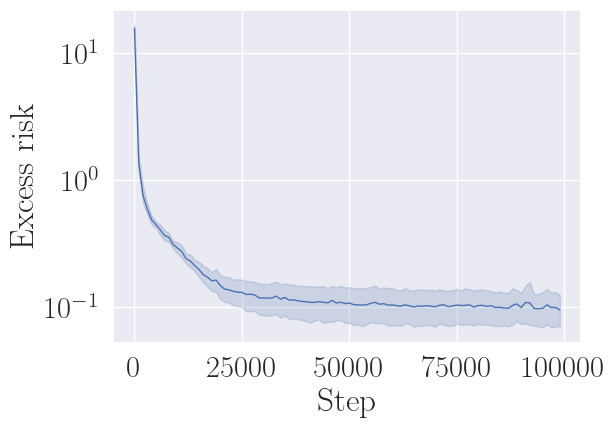

In [9]:
sns.lineplot(
    df,
    x="Step",
    y="Excess risk",
    linewidth=1.0,
)
plt.tight_layout()
plt.yscale('log')
plt.savefig("figures/excess_risk_toy_multihead.pdf", bbox_inches="tight")
plt.show()

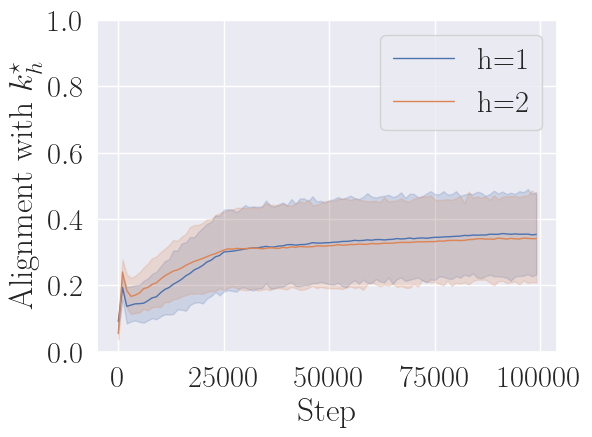

In [10]:
sns.lineplot(df, x="Step", y="Kappa1", linewidth=1.0, label="h=1")
sns.lineplot(df, x="Step", y="Kappa2", linewidth=1.0, label="h=2")
plt.tight_layout()
plt.ylim([0,1])
plt.ylabel(r"Alignment with $k_h^\star$")
plt.legend()
plt.savefig("figures/alignment_k_toy_multihead.pdf", bbox_inches="tight")
plt.show()

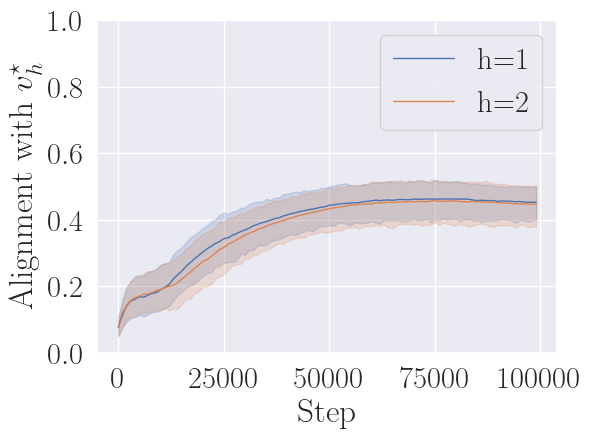

In [11]:
sns.lineplot(df, x="Step", y="Nu1", linewidth=1.0, label="h=1")
sns.lineplot(df, x="Step", y="Nu2", linewidth=1.0, label="h=2")
plt.tight_layout()
plt.ylim([0,1])
plt.ylabel(r"Alignment with $v_h^\star$")
plt.legend()
plt.savefig("figures/alignment_v_toy_multihead.pdf", bbox_inches="tight")
plt.show()